# Instructions

1. Make sure to save your desired NN architecture using the "SAVE" button. Follow the cell order in the notebook.

![Grafico de Red](https://imgur.com/6im6PUB.png)

2. When configuring the network architecture, do not forget to press the blue "SAVE" button. Without doing so, the subsequent cells will not work.

3. There are two modes: manual mode and training mode. The first mode is used for verifications by the TAs and the Professor. It is active with

![Manual Mode](https://imgur.com/bVqu5aR.png)

4. The training mode (mode_manual = False) has the same functionalities but with the printers deactivated. In either case, you need to have a network architecture configured.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
import ipywidgets as widgets
from IPython.display import display
# global numpy configurations
np.set_printoptions(precision=5, suppress=True, floatmode='fixed')
%precision 5

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'%.5f'

# Defining the Architecture of NN
After running this cell, you must press the Save button so that the NN structure is loaded.

In [ ]:
saved_experiments = []

In [ ]:
# Style wedgets
width_style = {'description_width': '70px'}
layout_width = widgets.Layout(width='200px')
slider_layout = widgets.Layout(width='120px')
# Creating widgets
text_input = widgets.Textarea(
    value="""You should train neural networks using different values of the regularization parameter λ,
and different network architectures. You may decide which architectures to evaluate. For example,
you might test networks with 1, 2, 3, and 4 hidden layers, and vary the number of neurons per layer,
such as 2, 4, 8, and 16. Examples: [1 2 1], [2 4 3 2]
""",
    description='Instructions:',
    layout=widgets.Layout(width='80%', height='110px')
)
input_layer = widgets.Dropdown(
    options=[i for i in range(1, 17)],
    value=1,
    description='📱input_layer',
    layout=slider_layout,
    style=width_style
)
hidden_layer_1 = widgets.Dropdown(
    options=[i for i in range(0, 17)],
    value=2,
    description='📲 Hidden_1',
    layout=slider_layout,
    style=width_style
)
hidden_layer_2 = widgets.Dropdown(
    options=[i for i in range(0, 17)],
    value=0,
    description='📲 Hidden_2',
    layout=slider_layout,
    style=width_style
)
hidden_layer_3 = widgets.Dropdown(
    options=[i for i in range(0, 17)],
    value=0,
    description='📲 Hidden__3',
    layout=slider_layout,
    style=width_style
)
hidden_layer_4 = widgets.Dropdown(
    options=[i for i in range(0, 17)],
    value=0,
    description='📲 Hidden__4',
    layout=slider_layout,
    style=width_style
)
output_layer = widgets.Dropdown(
    options=[i for i in range(1, 17)],
    value=1,
    description='📱 output_layer',
    layout=slider_layout,
    style=width_style
)
ui_horizontal = widgets.HBox(
    [input_layer, hidden_layer_1, hidden_layer_2, hidden_layer_3, hidden_layer_4, output_layer],
    layout=widgets.Layout(
    justify_content='space-between',
    width='80%'
)
)
input_regularization = widgets.FloatText(
    value=0.01,
    step=0.01,
    description='📈 Regularization (λ):',
    style={'description_width': '130px'},
    layout=layout_width
    )
btn_save = widgets.Button(description='Save', button_style='info')

# Saving the architecture
architecture = {}
def configure_architecture(n_in=None, n_hid=None, n_out=None, lmb=None):
  global architecture
  global reg_lambda
  # If parameters are passed (Automation), it uses them
  # If not (Button), it reads the widgets
  n_input = n_in if n_in is not None else input_layer.value
  n_hidden = n_hid if n_hid is not None else [h.value for h in [hidden_layer_1, hidden_layer_2, hidden_layer_3, hidden_layer_4] if h.value > 0]
  n_output = n_out if n_out is not None else output_layer.value
  reg_lambda = lmb if lmb is not None else input_regularization.value
  architecture['n_input'] = n_input
  architecture['n_hidden'] = n_hidden
  architecture['n_output'] = n_output
  architecture['reg_lambda'] = reg_lambda
  architecture['architecture'] = [n_input] + n_hidden + [n_output]
  print('*'*140)
  print(f'✅ Configuration saved:')
  print(f'❄️ Architecture: {architecture['architecture']} | λ: {reg_lambda}')

btn_save._click_handlers.callbacks = []
def on_button_clicked(monica):
    configure_architecture()
    # It is used for creating of list
    current_config = architecture.copy()
    saved_experiments.append(current_config)

btn_save.on_click(on_button_clicked)


In [ ]:
display(text_input, ui_horizontal, input_regularization, btn_save)

Textarea(value='You should train neural networks using different values of the regularization parameter λ,\nan…

FloatText(value=0.01, description='📈 Regularization (λ):', layout=Layout(width='200px'), step=0.01, style=Desc…

Button(button_style='info', description='Save', style=ButtonStyle())

********************************************************************************************************************************************
✅ Configuration saved:
❄️ Architecture: [2, 4, 3, 2] | λ: 0.01


In [ ]:
# ===============================================================
# Testing data backprop_example1 and backprop_example2 in HW5
# ===============================================================
backprop_examples = {
    'backprop_example1': {
        'thetas': {
            'theta_1': np.array([
                [0.40000, 0.10000],
                [0.30000, 0.20000]
            ]),
            'theta_2': np.array([
                [0.70000, 0.50000, 0.60000]
            ])
        },
        'X': np.array([
            [0.13000],
            [0.42000]
        ]),
        'y': np.array([
            [0.90000],
            [0.23000]
        ])
    },

    'backprop_example2': {
        'thetas': {
            'theta_1': np.array([
                [0.42000, 0.15000, 0.40000],
                [0.72000, 0.10000, 0.54000],
                [0.01000, 0.19000, 0.42000],
                [0.30000, 0.35000, 0.68000]
            ]),
            'theta_2': np.array([
                [0.21000, 0.67000, 0.14000, 0.96000, 0.87000],
                [0.87000, 0.42000, 0.20000, 0.32000, 0.89000],
                [0.03000, 0.56000, 0.80000, 0.69000, 0.09000]
            ]),
            'theta_3': np.array([
                [0.04000, 0.87000, 0.42000, 0.53000],
                [0.17000, 0.10000, 0.95000, 0.69000]
            ])
        },
        'X': np.array([
            [0.32000, 0.68000],
            [0.83000, 0.02000]
        ]),
        'y': np.array([
            [0.75000, 0.98000],
            [0.75000, 0.28000]
        ])
    }
}

# Dynamic architecture based on the network's input configuration

It has a manual mode and an automatic mode. The first is for testing with the examples. The second is for training the neural network.

In [ ]:
def creating_thetas(X, mode_manual = True, example='backprop_example1'):

  if mode_manual:
    data = backprop_examples[example]
    thetas = data['thetas']
    X = data['X']
    y = data['y']
    return thetas, X, y

  # ===============================================================
  # Dynamic architecture based on the network's input configuration
  # ===============================================================
  if mode_manual == False:
    #print('*'*140)
    #print('Creating thetas in NN training mode ...')
    #print('*'*140)
    thetas = {}
    # Replacing the initial '1' with the number of columns of X
    architecture['architecture'][0] = X.shape[1]
    arch_list = architecture['architecture']
    for i in range(len(architecture['architecture']) - 1):
      name = f'theta_{i+1}'
      rows = architecture['architecture'][i+1]
      cols = architecture['architecture'][i] + 1
      thetas[name] = np.random.randn(rows, cols)
      #print(f"DEBUG: Thetas created: {list(thetas.keys())}")

  return thetas, None, None

# Prepare the data you want to work with (backprop_example2 or backprop_example1)

In [ ]:
# ==================================================================
# Checking here the example !!!...
# ==================================================================

example='backprop_example2'
# ==================================================================
thetas, X, y = creating_thetas(_, mode_manual = True, example=example)
if X is None:
  print('='*140)
  print(f'The theta matrix data for training mode is \n {thetas}')
  print('='*140)
else:
  print('='*140)
  print(f'The testing data is working with the {example}')
  print('='*140)
  print(f'Thetas: {thetas}')
  print(f'X: {X}')
  print(f'y: {y}')

The testing data is working with the backprop_example2
Thetas: {'theta_1': array([[0.42000, 0.15000, 0.40000],
       [0.72000, 0.10000, 0.54000],
       [0.01000, 0.19000, 0.42000],
       [0.30000, 0.35000, 0.68000]]), 'theta_2': array([[0.21000, 0.67000, 0.14000, 0.96000, 0.87000],
       [0.87000, 0.42000, 0.20000, 0.32000, 0.89000],
       [0.03000, 0.56000, 0.80000, 0.69000, 0.09000]]), 'theta_3': array([[0.04000, 0.87000, 0.42000, 0.53000],
       [0.17000, 0.10000, 0.95000, 0.69000]])}
X: [[0.32000 0.68000]
 [0.83000 0.02000]]
y: [[0.75000 0.98000]
 [0.75000 0.28000]]


# Step forward propagation

In [ ]:
def calculate_J(y_true, y_pred, thetas=None, lambd=0):

  # Using logistic regression
  m = len(y_true)
  term1 = y_true * np.log(y_pred)
  term2 = (1 - y_true) * np.log(1 - y_pred)
  J_aux = -np.sum(term1 + term2) / len(y_true)

  # Adding regularization
  reg_term = 0
  if thetas is not None and lambd > 0:
    for theta in thetas.values():
      reg_term += np.sum(np.square(theta[:, 1:]))
    reg_term = (lambd / (2 * m)) * reg_term

  return J_aux + reg_term

def forward_step(X, y, thetas, manual_mode = False,  example=example, lambd=0):

  m = len(X)
  total_J = 0
  all_activations = {f'instancia_{i}': {} for i in range(len(X))}

  # The activation function will be the sigmoid
  sigmoid = lambda z: 1 / (1 + np.exp(-z))

  # ==================================================================
  # Manual mode for checking
  # ==================================================================
  if manual_mode == True:

    for i in range(len(X)):
      x_instance = X[i:i+1]
      y_instance = y[i:i+1]

      print('*'*140)
      print(f'Forward step: Working in the manual mode with instance {i+1} and the example {example} ...')
      print('*'*140)
      print('\n')

      X_bias = np.hstack((np.ones((1, 1)), x_instance))
      activations = {}
      activations['a1'] = X_bias
      print(f"a1: {X_bias[0]}")
      current_a = X_bias
      for j, (name, theta) in enumerate(thetas.items()):
        z = current_a @ theta.T
        print(f'z{i+2}: {z[0]}')
        # calculating activation
        a_next = sigmoid(z)
        if j < len(thetas) - 1:
          current_a = np.hstack((np.ones((1, 1)), a_next))
          activations[f'a{j+2}'] = current_a
          print(f'a{j+2}: {activations[f"a{j+2}"][0]}')
        else:
          activations[f'a{j+2}'] = a_next
          print(f'a{j+2}: {activations[f'a{j+2}'][0]}')
      f_x = a_next[0]
      J = calculate_J(y_instance, f_x, thetas, lambd=0)
      total_J += J
      J_final = total_J / m
      all_activations[f'instancia_{i}'] = activations
      print(f'f(x) = {f_x}')
      print(f'The cost function J={J}')

  else:
      #print('Forward step: Working in the modo training of the NN model...')
      X_bias_total = np.hstack((np.ones((m, 1)), X))
      current_a = X_bias_total
      all_activations = {'a1': current_a}
      theta_list = list(thetas.values())

      for j, theta in enumerate(theta_list):
        z = current_a @ theta.T
        # Activations
        a_next = sigmoid(z)

        if j < len(theta_list) - 1:
          current_a = np.hstack((np.ones((m, 1)), a_next))
          all_activations[f'a{j+2}'] = current_a
        else:
          all_activations[f'a{j+2}'] = a_next
      # Calculating J final
      f_x_total = all_activations[f'a{len(theta_list) + 1}']
      J_final = calculate_J(y, f_x_total, thetas, lambd=0)

  return all_activations, J_final

# Step Backpropagation (Learning)

In [ ]:
def backpropagation_step(X, y, activations_forward, manual_mode = True,  example=example, alpha=0.11):

  # Initializating accumulators for the gradients
  deltas_thetas_total = {f'delta_theta_{l}': np.zeros_like(thetas[f'theta_{l}']) for l in range(1, len(thetas)+1)}
  m = len(y)

  if manual_mode == True:
    print('*'*140)
    print(f'Backpropagation: Working in the manual mode with example {example} ...')
    print('*'*140)

    for i in range(len(X)):

      activations = activations_forward[f'instancia_{i}']
      y_instance = y[i:i+1]

      # ==================================================================
      # delta = (f(x) - y)
      # ==================================================================
      deltas = {}
      deltas_thetas = {}

      # Identification of last layer
      layer_index = [k for k in activations.keys() if k.startswith('a')]
      last_layer = sorted([int(k[1:]) for k in layer_index])[-1]

      # Output layer delta or prediction error
      f_x = activations[f'a{last_layer}']
      deltas[f'delta_{last_layer}'] = f_x - y_instance
      d_last = deltas[f'delta_{last_layer}']

      # Gradients of theta in (last_layer-1)
      deltas_thetas[f'delta_theta_{last_layer-1}'] = d_last.T @ activations[f'a{last_layer-1}']

      # Accumulation for the final average
      deltas_thetas_total[f'delta_theta_{last_layer-1}'] += deltas_thetas[f'delta_theta_{last_layer-1}']

      # Hidden layer delta's
      for l in range(last_layer - 1, 1, -1): # layer 1 (input) does not have a delta
        theta_l = thetas[f'theta_{l}']
        delta_next = deltas[f'delta_{l+1}']
        theta_no_bias = theta_l[:, 1:]

        a_current = activations[f'a{l}'][:, 1:]

        # Gradients of deltas
        error_term = delta_next @ theta_no_bias
        deltas[f'delta_{l}'] = error_term * a_current * (1 - a_current)

        # Gradients of thetas
        delta_l = deltas[f'delta_{l}']
        delta_theta = delta_l.T @ activations[f'a{l-1}']
        deltas_thetas[f'delta_theta_{l-1}'] = delta_theta

        # Acumulations
        deltas_thetas_total[f'delta_theta_{l-1}'] += delta_theta

        print('\n')
        print(f'Computing gradients in backpropagation with instances {i+1}...')
        print('='*140)
        print(f'Gradients delta: {deltas}')
        print(f'Gradients thetas: {deltas_thetas}')

    # ==================================================================
    # COMPUTING AVERAGE REGULARIZED GRADIENTS (Al final del modo manual)
    # ==================================================================
    print('\n' + '='*140)
    print("Computing the average (regularized) gradients:")
    print('='*140)
    for l in range(1, len(thetas) + 1):
      avg_grad = deltas_thetas_total[f'delta_theta_{l}'] /m
      # Deleting bias
      theta_reg = np.copy(thetas[f'theta_{l}'])
      theta_reg[:, 0] = 0
      # Regularized final gradient
      final_grad = avg_grad + (alpha/m) * theta_reg
      print(f'Final regularized gradients of theta{l}:')
      print(f'{final_grad}\n')

  else:
    #print(f'Backpropagation: Working in the training NN mode ...')

    activations = activations_forward
    layer_index = [k for k in activations.keys() if k.startswith('a')]
    last_layer = sorted([int(k[1:]) for k in layer_index])[-1]

    # Output layer delta or prediction error
    f_x = activations[f'a{last_layer}']

    deltas = {}
    deltas_thetas = {}
    deltas[f'delta_{last_layer}'] = f_x - y
    d_last = deltas[f'delta_{last_layer}']
    deltas_thetas_total[f'delta_theta_{last_layer-1}'] = d_last.T @ activations[f'a{last_layer-1}']

    # Hidden layer delta's
    for l in range(last_layer - 1, 1, -1):

      if f'theta_{l}' not in thetas:
                print(f"⚠️ Error: An attempt was made to access theta_l, but it does not exist.")
                print(f"Thetas disponibles: {list(thetas.keys())}")
                break

      theta_next_layer = thetas[f'theta_{l}']
      delta_of_next_layer = deltas[f'delta_{l+1}']

      # Deleting the bias
      theta_no_bias = theta_next_layer[:, 1:]

      # Assigning activations
      a_current = activations[f'a{l}'][:, 1:]
      error_term = delta_of_next_layer @ theta_no_bias
      deltas[f'delta_{l}'] = error_term * a_current * (1 - a_current)

      # Calculating The Anterior Theta Gradient
      delta_l = deltas[f'delta_{l}']
      # (neurons_l x m) @ (m x neurons_l-1)
      deltas_thetas[f'delta_theta_{l-1}'] = delta_l.T @ activations[f'a{l-1}']

      #print(f'delta_theta_{l-1}: {deltas_thetas[f'delta_theta_{l-1}'].shape}')
      #print(f'activations: {activations[f'a{l-1}'].shape}')

    # ==================================================================
    # COMPUTING AVERAGE REGULARIZED GRADIENTS (Igual al final del manual)
    # ==================================================================

    final_grad = {}
    for l in range(1, len(thetas) + 1):
        avg_grad = deltas_thetas_total[f'delta_theta_{l}'] / m
        theta_reg = np.copy(thetas[f'theta_{l}'])
        theta_reg[:, 0] = 0
        final_grad[f'delta_theta_{l}'] = avg_grad + (alpha/m) * theta_reg
        #print(f'Final regularized gradients of theta{l}:')
        #print(f'{final_grad}\n')

    return final_grad

# Manual Mode
                                                

In [ ]:
custom_layout = widgets.Layout(width='300px', height='80px')
btn_manual_mode = widgets.Button(description='Manual Mode (click)', button_style='info', layout=custom_layout)
btn_manual_mode.style.font_weight = 'bold'
btn_manual_mode.style.button_color = '#00bca8'
def on_click_manual(b):
  print('\n' + '='*50)
  print('Running manual mode ...')
  print('='*50 + '\n')
  # calling functions ...
  activations, j_val = forward_step(X, y, thetas, manual_mode=True)
  backpropagation_step(X, y, activations, manual_mode=True)
btn_manual_mode.on_click(on_click_manual)
display(btn_manual_mode)

Button(button_style='info', description='Manual Mode (click)', layout=Layout(height='80px', width='300px'), st…


Running manual mode ...

********************************************************************************************************************************************
Forward step: Working in the manual mode with instance 1 and the example backprop_example2 ...
********************************************************************************************************************************************


a1: [1.00000 0.32000 0.68000]
z2: [0.74000 1.11920 0.35640 0.87440]
a2: [1.00000 0.67700 0.75384 0.58817 0.70566]
z2: [1.94769 2.12136 1.48154]
a3: [1.00000 0.87519 0.89296 0.81480]
z2: [1.60831 1.66805]
a4: [0.83318 0.84132]
f(x) = [0.83318 0.84132]
The cost function J=0.7907366961135718
********************************************************************************************************************************************
Forward step: Working in the manual mode with instance 2 and the example backprop_example2 ...
*********************************************************************

# Training Mode (The assignment 5 starts here). Check the architecture saved.

In [ ]:
if architecture:
  print('*'*140)
  print(f'✅ Configuration saved:')
  print(f'❄️ Architecture: {architecture['architecture']} | λ: {reg_lambda}')
  print('*'*140)

********************************************************************************************************************************************
✅ Configuration saved:
❄️ Architecture: [1, 2, 1] | λ: 0.01
********************************************************************************************************************************************


# wdbc dataset  

In [ ]:
dataset_wdbc = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML_class/HW4_CMPSCI_589_Spring2026_Supporting_Files/datasets/wdbc.csv')
dataset_wdbc.head(3)

,attr1_num,attr2_num,attr3_num,attr4_num,attr5_num,attr6_num,attr7_num,attr8_num,attr9_num,attr10_num,...,attr22_num,attr23_num,attr24_num,attr25_num,attr26_num,attr27_num,attr28_num,attr29_num,attr30_num,label
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


# Pre-processing wdbc data

In [ ]:
X = dataset_wdbc.drop(columns=['label'])
y = dataset_wdbc['label'].values
# normalize
X_normal = (X - X.min()) / (X.max() - X.min())

# Cross-Validation wdbc data

In [ ]:
# Cross-Validation (Stratified K-Fold) Training and test (no validation part)
def cross_validation_stratified(X_normal, y, k = 10):

  n = len(X_normal)
  index_total = np.arange(n)
  # Cutoff point for Cross-Validation, 70% training, 15% validation, 15% test dataset
  split_point = int(n * 0.85)
  train_index = index_total[:split_point]
  test_index = index_total[split_point:]
  # identification of labels for cross-validation
  y_train = y[train_index]
  # identification of each class for cross-validation
  idx_0 = train_index[y_train == 0]
  idx_1 = train_index[y_train == 1]
  # Shuffle
  np.random.shuffle(idx_0)
  np.random.shuffle(idx_1)
  # Split
  splits_0 = np.array_split(idx_0, k)
  splits_1 = np.array_split(idx_1, k)
  folds = []
  for i in range(k):
    fold_id = np.concatenate([splits_0[i], splits_1[i]])
    np.random.shuffle(fold_id)
    folds.append(fold_id)
  return folds, test_index
# Calling the function
folds_index, data_test_idx = cross_validation_stratified(X_normal, y, k = 10)

# Traning and evaluation of the NN using stratified cross-validation wdbc data

In [ ]:
def train_validation_full_model(X_normal, y, folds_index, n_in, n_hid, n_out, lamb):

  configure_architecture(n_in=n_in, n_hid=n_hid, n_out=n_out, lmb=lamb)

  max_epochs = 100
  epsilon = 1e-5
  alpha = 0.11
  batch_size = 32

  fold_accuracies = []
  fold_losses = []
  fold_f1_scores = []

  for f_idx in range(len(folds_index)):

    #print('\n')
    #print('='*140)
    #print(f'Working with fold {f_idx + 1} in modo mini-batch ...')

    # ==================================================================
    # PREPARING THE FOLD DATA
    # ==================================================================

    val_idx = folds_index[f_idx]
    train_idx = np.concatenate([folds_index[j] for j in range(len(folds_index)) if j != f_idx])

    X_train_f = X_normal.iloc[train_idx].values
    y_train_f = y[train_idx].reshape(-1, 1)

    X_val_f = X_normal.iloc[val_idx].values
    y_val_f = y[val_idx].reshape(-1, 1)
    #print(f'X_train_f: {X_train_f.shape}')
    #print(f'y_train_f: {y_train_f.shape}')

    prev_J_epoch = float('inf')
    epoch_cost = 0

    # ==================================================================
    # THETA RESET
    # ==================================================================
    thetas_full, _, _ = creating_thetas(X_train_f, mode_manual = False)
    global thetas
    thetas = thetas_full

    # ==================================================================
    # TRAINING LOOP
    # ==================================================================
    for epoch in range(max_epochs):

      epoch_cost = 0
      # Shuffling is performed at the beginning of each epoch
      index = np.arange(len(X_train_f))
      np.random.shuffle(index)
      X_shuffled = X_train_f[index]
      y_shuffled = y_train_f[index]

      # Loop for mini-batch
      for start in range(0, len(X_train_f), batch_size):
        end = start + batch_size
        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        # Forward step
        activations, batch_J = forward_step(X_batch, y_batch, thetas, manual_mode = False,  example=example, lambd=0.01)
        epoch_cost += batch_J

        # Backpropagation step
        gradients = backpropagation_step(X_batch, y_batch, activations, manual_mode = False,  example=example, alpha=alpha)
        # Weight update, performed after each batch
        for l in range(1, len(thetas) + 1):
          thetas[f'theta_{l}'] -= alpha * gradients[f'delta_theta_{l}']

      # Stopping criterion: Evaluated at the end of the epoch (average of the batches)
      total_batches = np.ceil(len(X_train_f) / batch_size)
      avg_epoch_cost = epoch_cost / total_batches
      #print(f'Epoch {epoch + 1}/{max_epochs} | Cost: {avg_epoch_cost}')

      #if abs(prev_J_epoch - avg_epoch_cost) < epsilon:
        #print(f"Convergence in an epoch {epoch}. Cost: {avg_epoch_cost:.6f}")
        #break

      prev_J_epoch = avg_epoch_cost

      #if (epoch + 1) % 100 == 0:
        #print(f"Epoch {epoch + 1} - Cost average: {avg_epoch_cost:.6f}")

    # ==================================================================
    # EVALUATION
    # ==================================================================
    val_activations, val_loss = forward_step(X_val_f, y_val_f, thetas, manual_mode=False)
    #print(f'Validation loss: {val_loss}')
    # Prediction in the last layer
    last_layer = sorted([int(k[1:]) for k in val_activations.keys() if k.startswith('a')])[-1]
    y_pred = val_activations[f'a{last_layer}']
    # Accuracy
    pred_bin = (y_pred >= 0.5).astype(int)
    accuracy_fold = np.mean(pred_bin == y_val_f)
    fold_losses.append(val_loss)
    fold_accuracies.append(accuracy_fold)
    # F1-Score
    tp = np.sum((pred_bin == 1) & (y_val_f == 1))
    fp = np.sum((pred_bin == 1) & (y_val_f == 0))
    fn = np.sum((pred_bin == 0) & (y_val_f == 1))
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1_score = 2 * (precision * recall) / (precision + recall)
    fold_f1_scores.append(f1_score)
    #print(f"Results Fold {f_idx + 1}: Accuracy = {accuracy_fold:.4f}, F1-Score: {f1_score:.4f}, Loss = {val_loss:.4f}")
  return np.mean(fold_accuracies), np.mean(fold_f1_scores)

# Testing with different architectures on wdbc data

In [ ]:
saved_experiments = []
display(text_input, ui_horizontal, input_regularization, btn_save)

Textarea(value='You should train neural networks using different values of the regularization parameter λ,\nan…

FloatText(value=0.01, description='📈 Regularization (λ):', layout=Layout(width='200px'), step=0.01, style=Desc…

Button(button_style='info', description='Save', style=ButtonStyle())

********************************************************************************************************************************************
✅ Configuration saved:
❄️ Architecture: [1, 2, 1] | λ: 0.01
********************************************************************************************************************************************
✅ Configuration saved:
❄️ Architecture: [1, 4, 1] | λ: 0.01
********************************************************************************************************************************************
✅ Configuration saved:
❄️ Architecture: [1, 8, 1] | λ: 0.01
********************************************************************************************************************************************
✅ Configuration saved:
❄️ Architecture: [1, 16, 1] | λ: 0.01
********************************************************************************************************************************************
✅ Configuration saved:
❄️ Architecture: [1, 2, 1] | λ:

# Table with results for wdbc data

In [ ]:
final_results = []

print(f'🔬 Starting a batch of {len(saved_experiments)} experiments...')

# Iterate over yhe list of dictionaries
for i, config in enumerate(saved_experiments):
    #print(f"\n" + "·"*60)
    #print(f"TEST #{i+1}: Architecture {config['architecture']} | λ: {config['reg_lambda']}")
    # Calling training function using the dictionary keys
    try:
        avg_acc, avg_f1 = train_validation_full_model(
            X_normal,
            y,
            folds_index,
            n_in=config['n_input'],
            n_hid=config['n_hidden'],
            n_out=config['n_output'],
            lamb=config['reg_lambda']
        )
        # Save the results
        final_results.append({
            'ID': i + 1,
            'Hidden_Layers': len(config['n_hidden']),
            'Neurons': str(config['n_hidden']),
            'Lambda': config['reg_lambda'],
            'Mean_Accuracy': avg_acc,
            'Mean_F1_Score': avg_f1
        })
    except Exception as e:
        print(f'❌ Error in experiment {i+1}: {e}')

# Convert to DataFrame
df_summary = pd.DataFrame(final_results)

print('\n" + "🏆 FINAL RESULTS ORDERED BY ACCURACY')
display(df_summary.sort_values(by='Mean_Accuracy', ascending=False))

🔬 Starting a batch of 19 experiments...

🏆 FINAL RESULTS ORDERED BY ACCURACY


,ID,Hidden_Layers,Neurons,Lambda,Mean_Accuracy,Mean_F1_Score
3,4,1,[16],0.01,0.912840,0.932225
7,8,1,[16],10.00,0.898597,0.922056
2,3,1,[8],0.01,0.857100,0.895322
6,7,1,[8],10.00,0.846811,0.890311
1,2,1,[4],0.01,0.747747,0.831165
5,6,1,[4],10.00,0.730230,0.819706
0,1,1,[2],0.01,0.718282,0.814034
10,11,2,"[8, 16]",0.10,0.664881,0.785788
9,10,2,"[16, 8]",0.10,0.662713,0.784302
4,5,1,[2],10.00,0.654422,0.779469


# Identify the best model from results with wdbc data (Deployment Model)

🏆 Evaluating the winning Model on the 15% test set:
Architecture: [1, 16, 1] | λ: 0.01



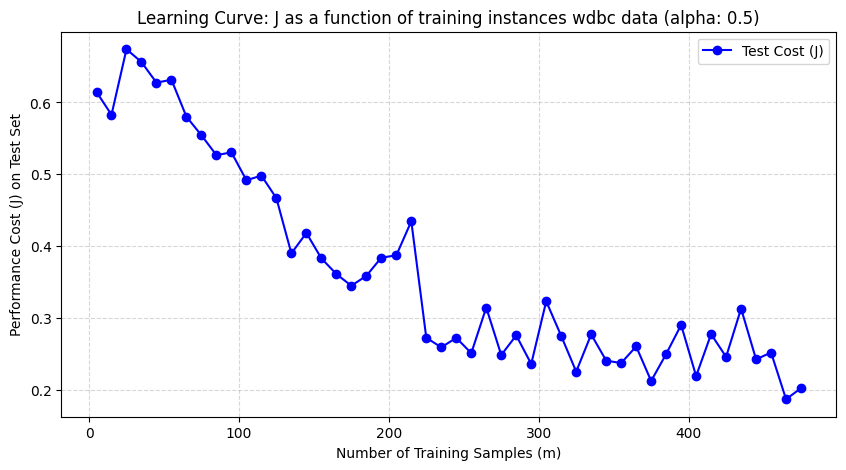

************************************************************
🎯 LEARNING CURVE COMPLETED
Value alpha: 0.5
************************************************************
************************************************************
FINAL TEST SET RESULTS
Final Accuracy: 0.9535
Final F1-Score: 0.9688
************************************************************


In [ ]:
# Get the best configuration
best_idx = df_summary['Mean_Accuracy'].idxmax()
best_config = saved_experiments[best_idx]

print(f'🏆 Evaluating the winning Model on the 15% test set:')
print(f'Architecture: {best_config["architecture"]} | λ: {best_config["reg_lambda"]}\n')

all_indices = np.arange(len(X_normal))
train_indices = np.setdiff1d(all_indices, data_test_idx)

# Training data (85%)
X_train_final = X_normal.iloc[train_indices].values
y_train_final = y[train_indices].reshape(-1, 1)

# Shuffle index
shuffled_idx = np.random.permutation(len(X_train_final))

X_train_shuffled = X_train_final[shuffled_idx]
y_train_shuffled = y_train_final[shuffled_idx]

# Test data (15%)
X_test_final = X_normal.iloc[data_test_idx].values
y_test_final = y[data_test_idx].reshape(-1, 1)

# Variables for the Learning Curve
m_sizes = np.arange(5, len(X_train_final), 10)
test_costs_j = []
alpha = 0.5#0.11, 0.05

for m in m_sizes:
  # Training Subset Selection
  X_sub = X_train_shuffled[:m]
  y_sub = y_train_shuffled[:m]

  # configuration
  configure_architecture(
      n_in=X_sub.shape[1],
      n_hid=best_config['n_hidden'],
      n_out=best_config['n_output'],
      lmb=best_config['reg_lambda']
  )

  # Initialize Thetas
  thetas_final, _, _ = creating_thetas(X_sub, mode_manual=False)

  # Link to global state
  global thetas
  thetas = thetas_final

  for epoch in range(800):
    # Forward step
    activations, _ = forward_step(X_sub, y_sub, thetas, manual_mode=False)

    # Backpropagation step
    gradients = backpropagation_step(X_sub, y_sub, activations, manual_mode=False, alpha=alpha)

    # Weight update
    for l in range(1, len(thetas) + 1):
        thetas[f'theta_{l}'] -= alpha * gradients[f'delta_theta_{l}']

  # J cost
  _, j_test = forward_step(X_test_final, y_test_final, thetas, manual_mode=False)
  test_costs_j.append(j_test)

# Prediction
test_activations, _ = forward_step(X_test_final, y_test_final, thetas, manual_mode=False)
# Identify the last layer
last_layer_key = sorted([k for k in test_activations.keys() if k.startswith('a')])[-1]
y_prob = test_activations[last_layer_key]
y_pred = (y_prob >= 0.5).astype(int)

# metrics
final_accuracy = np.mean(y_pred == y_test_final)
tp = np.sum((y_pred == 1) & (y_test_final == 1))
fp = np.sum((y_pred == 1) & (y_test_final == 0))
fn = np.sum((y_pred == 0) & (y_test_final == 1))

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
final_f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(m_sizes, test_costs_j, color='blue', marker='o', label='Test Cost (J)')
plt.title(f'Learning Curve: J as a function of training instances wdbc data (alpha: {alpha})')
plt.xlabel('Number of Training Samples (m)')
plt.ylabel('Performance Cost (J) on Test Set')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

print('*' * 60)
print(f'🎯 LEARNING CURVE COMPLETED')
print(f'Value alpha: {alpha}')
print('*' * 60)

print('*' * 60)
print(f'FINAL TEST SET RESULTS')
print(f'Final Accuracy: {final_accuracy:.4f}')
print(f'Final F1-Score: {final_f1:.4f}')
print('*' * 60)

# Loan dataset

In [ ]:
dataset_loan = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML_class/HW4_CMPSCI_589_Spring2026_Supporting_Files/datasets/loan.csv')
dataset_loan.head(3)

,attr1_cat,attr2_cat,attr3_cat,attr4_cat,attr5_cat,attr6_num,attr7_num,attr8_num,attr9_num,attr10_cat,attr11_cat,label
0,Male,Yes,1,Graduate,No,4583,1508.0,128,360,1,Rural,0
1,Male,Yes,0,Graduate,Yes,3000,0.0,66,360,1,Urban,1
2,Male,Yes,0,Not Graduate,No,2583,2358.0,120,360,1,Urban,1


# One-Hot Encode multiple columns loan dataset

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Categorical and numerical columns
categorical_cols = [col for col in dataset_loan.columns if col.endswith('_cat')]
numerical_cols = [col for col in dataset_loan.columns if col.endswith('_num')]
# 'remainder=passthrough' --> numerical columns are not dropped
ct = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)
# Transform the data
X_transformed = ct.fit_transform(dataset_loan.drop(columns=['label']))
X_normal_loan = pd.DataFrame(X_transformed, columns=ct.get_feature_names_out())
# Get the target y
y_l = dataset_loan['label'].values

print(f'Original shape: {dataset_loan.shape}')
print(f'New shape after One-Hot: {X_transformed.shape}')
print(f'')

Original shape: (480, 12)
New shape after One-Hot: (480, 21)



In [ ]:
# normalize
X_normal_loan_train = (X_normal_loan - X_normal_loan.min()) / (X_normal_loan.max() - X_normal_loan.min())
X_normal_loan_train.head(3)

,onehot__attr1_cat_Female,onehot__attr1_cat_Male,onehot__attr2_cat_No,onehot__attr2_cat_Yes,onehot__attr3_cat_0,onehot__attr3_cat_1,onehot__attr3_cat_2,onehot__attr3_cat_3+,onehot__attr4_cat_Graduate,onehot__attr4_cat_Not Graduate,...,onehot__attr5_cat_Yes,onehot__attr10_cat_0,onehot__attr10_cat_1,onehot__attr11_cat_Rural,onehot__attr11_cat_Semiurban,onehot__attr11_cat_Urban,remainder__attr6_num,remainder__attr7_num,remainder__attr8_num,remainder__attr9_num
0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.054830,0.044567,0.201354,0.72973
1,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.035250,0.000000,0.096447,0.72973
2,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.030093,0.069687,0.187817,0.72973


# Cross-Validation Loan data

In [ ]:
folds_index, data_test_idx = cross_validation_stratified(X_normal_loan_train, y_l, k = 10)

# Table with results for Loan data

In [ ]:
final_results = []

print(f"🔬 Starting a batch of {len(saved_experiments)} experiments...")

# Iterate over yhe list of dictionaries
for i, config in enumerate(saved_experiments):
    #print(f"\n" + "·"*60)
    #print(f"TEST #{i+1}: Architecture {config['architecture']} | λ: {config['reg_lambda']}")
    # Calling training function using the dictionary keys
    try:
        avg_acc, avg_f1 = train_validation_full_model(
            X_normal_loan_train,
            y_l,
            folds_index,
            n_in=config['n_input'],
            n_hid=config['n_hidden'],
            n_out=config['n_output'],
            lamb=config['reg_lambda']
        )
        # Saving the results
        final_results.append({
            'ID': i + 1,
            'Hidden_Layers': len(config['n_hidden']),
            'Neurons': str(config['n_hidden']),
            'Lambda': config['reg_lambda'],
            'Mean_Accuracy': avg_acc,
            'Mean_F1_Score': avg_f1
        })
    except Exception as e:
        print(f"❌ Error in experiment {i+1}: {e}")

# Convert to DataFrame
df_summary = pd.DataFrame(final_results)

print('\n' + '🏆 FINAL RESULTS ORDERED BY ACCURACY')
display(df_summary.sort_values(by='Mean_Accuracy', ascending=False))

🔬 Starting a batch of 19 experiments...

🏆 FINAL RESULTS ORDERED BY ACCURACY


,ID,Hidden_Layers,Neurons,Lambda,Mean_Accuracy,Mean_F1_Score
3,4,1,[16],0.01,0.754695,0.844884
7,8,1,[16],10.00,0.754695,0.844893
6,7,1,[8],10.00,0.727988,0.834560
2,3,1,[8],0.01,0.725488,0.832550
5,6,1,[4],10.00,0.696402,0.817976
1,2,1,[4],0.01,0.691220,0.815265
10,11,2,"[8, 16]",0.10,0.688780,0.815175
9,10,2,"[16, 8]",0.10,0.688780,0.815175
11,12,3,"[4, 8, 16]",0.10,0.686341,0.813981
4,5,1,[2],10.00,0.686341,0.813981


# Identify the best model from results with Loan data (Deployment Model)

🏆 Evaluating the winning Model on the 15% test set:
Architecture: [1, 16, 1] | λ: 0.01



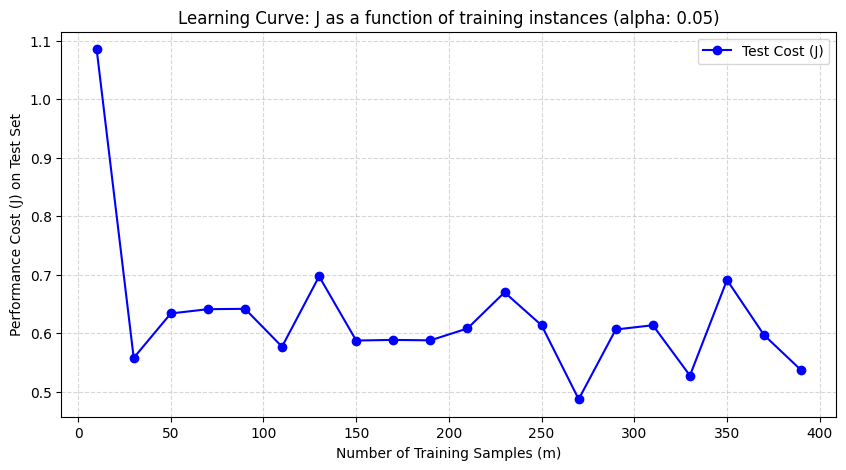

************************************************************
🎯 LEARNING CURVE COMPLETED
Value alpha: 0.05
************************************************************
************************************************************
FINAL TEST SET RESULTS
Final Accuracy: 0.7361
Final F1-Score: 0.8348
************************************************************


In [ ]:
# Get the best configuration
best_idx = df_summary['Mean_Accuracy'].idxmax()
best_config = saved_experiments[best_idx]

print(f'🏆 Evaluating the winning Model on the 15% test set:')
print(f'Architecture: {best_config["architecture"]} | λ: {best_config["reg_lambda"]}\n')

all_indices = np.arange(len(X_normal_loan_train))
train_indices = np.setdiff1d(all_indices, data_test_idx)

# Training data (85%)
X_train_final = X_normal_loan_train.iloc[train_indices].values
y_train_final = y_l[train_indices].reshape(-1, 1)

# Shuffle index
shuffled_idx = np.random.permutation(len(X_train_final))

X_train_shuffled = X_train_final[shuffled_idx]
y_train_shuffled = y_train_final[shuffled_idx]

# Test data (15%)
X_test_final = X_normal_loan_train.iloc[data_test_idx].values
y_test_final = y_l[data_test_idx].reshape(-1, 1)

# Variables for the Learning Curve
m_sizes = np.arange(10, len(X_train_shuffled), 20)
test_costs_j = []
alpha = 0.05

for m in m_sizes:
  # Training Subset Selection
  X_sub = X_train_shuffled[:m]
  y_sub = y_train_shuffled[:m]

  # configuration
  configure_architecture(
      n_in=X_sub.shape[1],
      n_hid=best_config['n_hidden'],
      n_out=best_config['n_output'],
      lmb=best_config['reg_lambda']
  )

  # Initialize Thetas
  thetas_final, _, _ = creating_thetas(X_sub, mode_manual=False)

  # Link to global state
  global thetas
  thetas = thetas_final

  for epoch in range(400):
    # Forward step
    activations, _ = forward_step(X_sub, y_sub, thetas, manual_mode=False)

    # Backpropagation step
    gradients = backpropagation_step(X_sub, y_sub, activations, manual_mode=False, alpha=alpha)

    # Weight update
    for l in range(1, len(thetas) + 1):
        thetas[f'theta_{l}'] -= alpha * gradients[f'delta_theta_{l}']

  # J cost
  _, j_test = forward_step(X_test_final, y_test_final, thetas, manual_mode=False)
  test_costs_j.append(j_test)

# Prediction
test_activations, _ = forward_step(X_test_final, y_test_final, thetas, manual_mode=False)
# Identify the last layer
last_layer_key = sorted([k for k in test_activations.keys() if k.startswith('a')])[-1]
y_prob = test_activations[last_layer_key]
y_pred = (y_prob >= 0.5).astype(int)

# metrics
final_accuracy = np.mean(y_pred == y_test_final)
tp = np.sum((y_pred == 1) & (y_test_final == 1))
fp = np.sum((y_pred == 1) & (y_test_final == 0))
fn = np.sum((y_pred == 0) & (y_test_final == 1))

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
final_f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(m_sizes, test_costs_j, color='blue', marker='o', label='Test Cost (J)')
plt.title(f'Learning Curve: J as a function of training instances (alpha: {alpha})')
plt.xlabel('Number of Training Samples (m)')
plt.ylabel('Performance Cost (J) on Test Set')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

print('*' * 60)
print(f'🎯 LEARNING CURVE COMPLETED')
print(f'Value alpha: {alpha}')
print('*' * 60)

print('*' * 60)
print(f'FINAL TEST SET RESULTS')
print(f'Final Accuracy: {final_accuracy:.4f}')
print(f'Final F1-Score: {final_f1:.4f}')
print('*' * 60)